# Diagnóstico Exploratorio de Datos: Yellow Tripdata 2025-01
Este notebook contiene el análisis exploratorio completo solicitado, identificando la calidad de datos, anomalías, e insights de negocio para el caso de estudio de Movilidad Urbana NYC.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

# Configuraciones iniciales
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.3f' % x)
os.makedirs('../graficos', exist_ok=True)
os.makedirs('../datos', exist_ok=True)
start_time = time.time()


## Paso 1: Carga y Exploración Básica

In [2]:
# Cargar datos crudos
print("Cargando el dataset...")
df = pd.read_parquet('../datos/raw/yellow_tripdata_2025-01.parquet')
lookup = pd.read_csv('../datos/raw/taxi_zone_lookup.csv')

print("A) Estructura del Dataset")
print(f"Total de filas: {df.shape[0]:,}")
print(f"Total de columnas: {df.shape[1]}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
display(df.dtypes.to_frame('Tipo de Dato'))

print("\nB) Cobertura Temporal")
print(f"Fecha mínima pickup: {df['tpep_pickup_datetime'].min()}")
print(f"Fecha máxima pickup: {df['tpep_pickup_datetime'].max()}")


Cargando el dataset...
A) Estructura del Dataset
Total de filas: 3,475,226
Total de columnas: 20
Tamaño en memoria: 493.47 MB


,Tipo de Dato
VendorID,int32
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,str
PULocationID,int32
DOLocationID,int32
payment_type,int64



B) Cobertura Temporal
Fecha mínima pickup: 2024-12-31 20:47:55
Fecha máxima pickup: 2025-02-01 00:00:44


## Paso 2: Análisis de Calidad - Nulos y Duplicados

A) Valores Nulos


,Cantidad Nulos,Porcentaje
passenger_count,540149,15.543
RatecodeID,540149,15.543
store_and_fwd_flag,540149,15.543
congestion_surcharge,540149,15.543
Airport_fee,540149,15.543


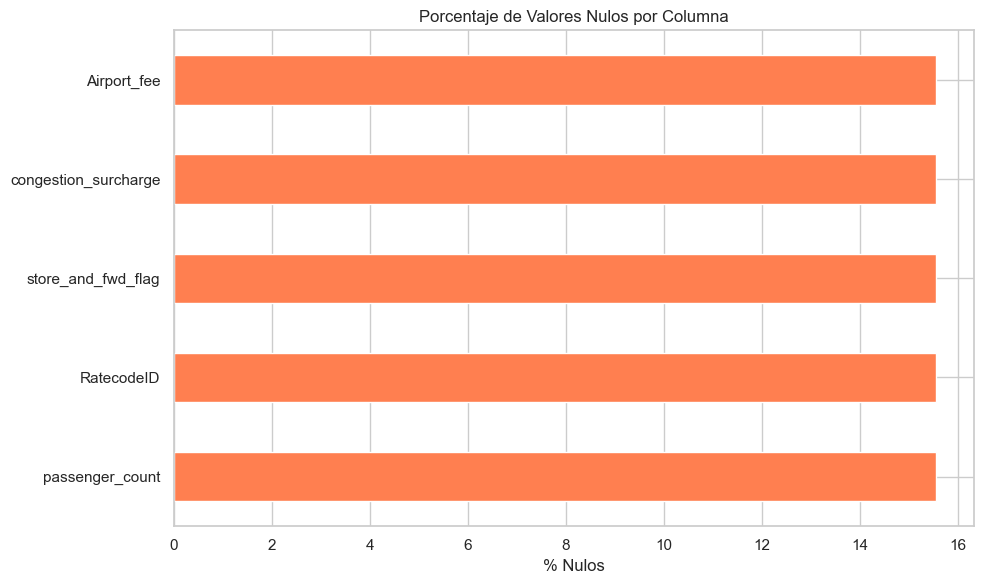


B) Duplicados Exactos
Filas completamente duplicadas: 0


In [4]:
print("A) Valores Nulos")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({'Cantidad Nulos': nulos, 'Porcentaje': porcentaje_nulos})
display(nulos_df[nulos_df['Cantidad Nulos'] > 0])

# Gráfico de nulos
plt.figure(figsize=(10, 6))
porcentaje_nulos[porcentaje_nulos > 0].sort_values().plot(kind='barh', color='coral')
plt.title('Porcentaje de Valores Nulos por Columna')
plt.xlabel('% Nulos')
plt.tight_layout()
plt.savefig('../graficos/05_nulos_por_columna.png')
plt.show()

print("\nB) Duplicados Exactos")
duplicados_exactos = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados_exactos}")


## Paso 3: Análisis de Integridad - Rangos y Coherencia

In [5]:
print("A) Tarifa (fare_amount)")
display(df['fare_amount'].describe())
tarifas_negativas = len(df[df['fare_amount'] < 0])
tarifas_altas = len(df[df['fare_amount'] > 500])
print(f"Tarifas negativas: {tarifas_negativas} ({(tarifas_negativas/len(df))*100:.4f}%)")
print(f"Tarifas muy altas (>500): {tarifas_altas}")

print("\nB) Distancia (trip_distance)")
display(df['trip_distance'].describe())
distancias_0 = len(df[df['trip_distance'] == 0])
distancias_imposibles = len(df[df['trip_distance'] > 100])
print(f"Viajes con distancia 0: {distancias_0} ({(distancias_0/len(df))*100:.2f}%)")
print(f"Viajes > 100 millas: {distancias_imposibles}")


A) Tarifa (fare_amount)


count   3475226.000
mean         17.082
std         463.473
min        -900.000
25%           8.600
50%          12.110
75%          19.500
max      863372.120
Name: fare_amount, dtype: float64

Tarifas negativas: 144118 (4.1470%)
Tarifas muy altas (>500): 55

B) Distancia (trip_distance)


count   3475226.000
mean          5.855
std         564.602
min           0.000
25%           0.980
50%           1.670
75%           3.100
max      276423.570
Name: trip_distance, dtype: float64

Viajes con distancia 0: 90893 (2.62%)
Viajes > 100 millas: 162


## Paso 4: Análisis de Distribuciones

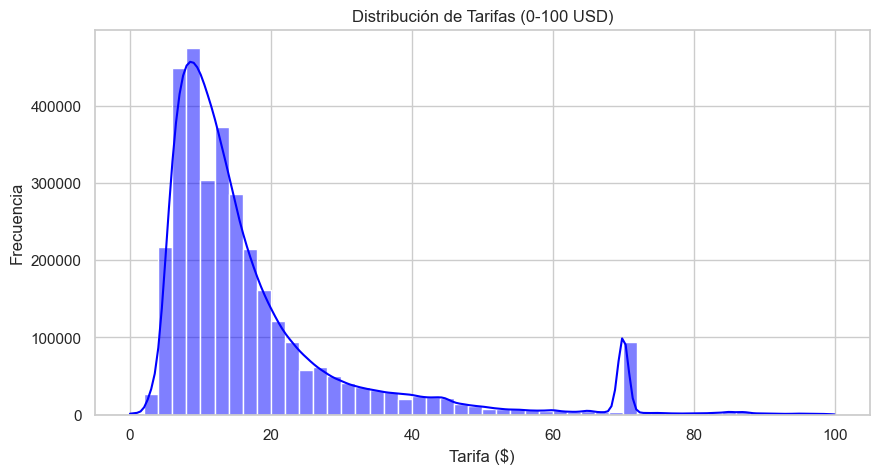

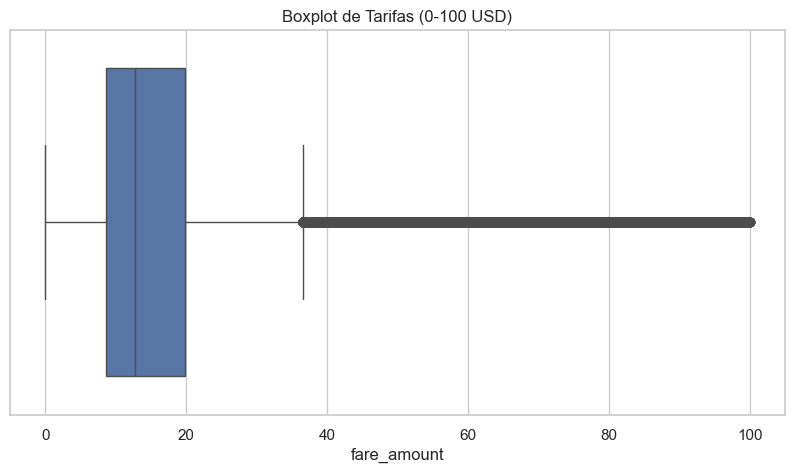

C:\Users\User\AppData\Local\Temp\ipykernel_30748\37183558.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['passenger_count'].notnull()], x='passenger_count', palette='viridis')


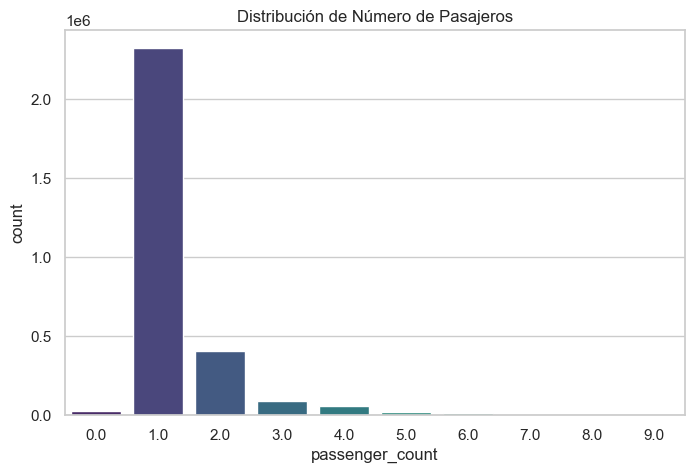

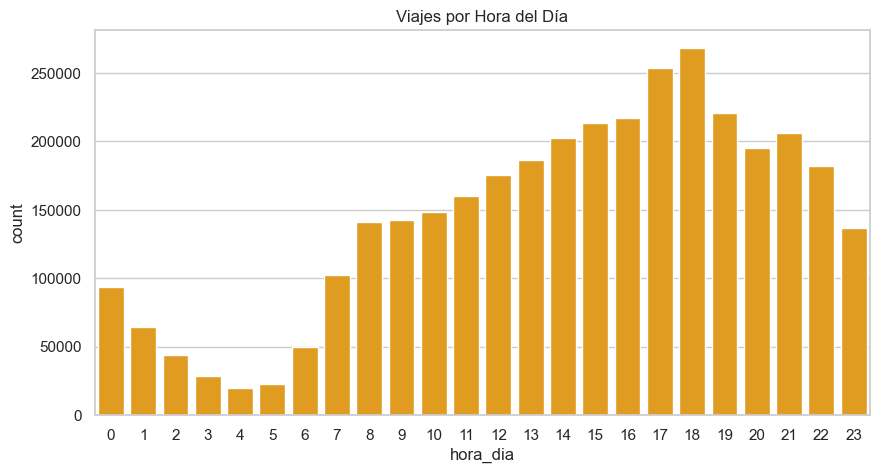

In [6]:
# Gráficos de distribución (filtrando outliers extremos para visualizar mejor)
df_valid_fare = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 100)]

plt.figure(figsize=(10, 5))
sns.histplot(df_valid_fare['fare_amount'], bins=50, kde=True, color='blue')
plt.title('Distribución de Tarifas (0-100 USD)')
plt.xlabel('Tarifa ($)')
plt.ylabel('Frecuencia')
plt.savefig('../graficos/01_distribucion_tarifas.png')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_valid_fare['fare_amount'])
plt.title('Boxplot de Tarifas (0-100 USD)')
plt.savefig('../graficos/11_boxplot_tarifas.png')
plt.show()

# Pasajeros
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df['passenger_count'].notnull()], x='passenger_count', palette='viridis')
plt.title('Distribución de Número de Pasajeros')
plt.savefig('../graficos/04_distribucion_pasajeros.png')
plt.show()

# Variables temporales para gráficos
df['hora_dia'] = df['tpep_pickup_datetime'].dt.hour
df['dia_semana'] = df['tpep_pickup_datetime'].dt.dayofweek

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='hora_dia', color='orange')
plt.title('Viajes por Hora del Día')
plt.savefig('../graficos/06_temporal_viajes_hora.png')
plt.show()


## Paso 5 y 6: Validación Geográfica y Vendors

C:\Users\User\AppData\Local\Temp\ipykernel_30748\1632414102.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_origen, y='Zone', x='Viajes', palette='magma')


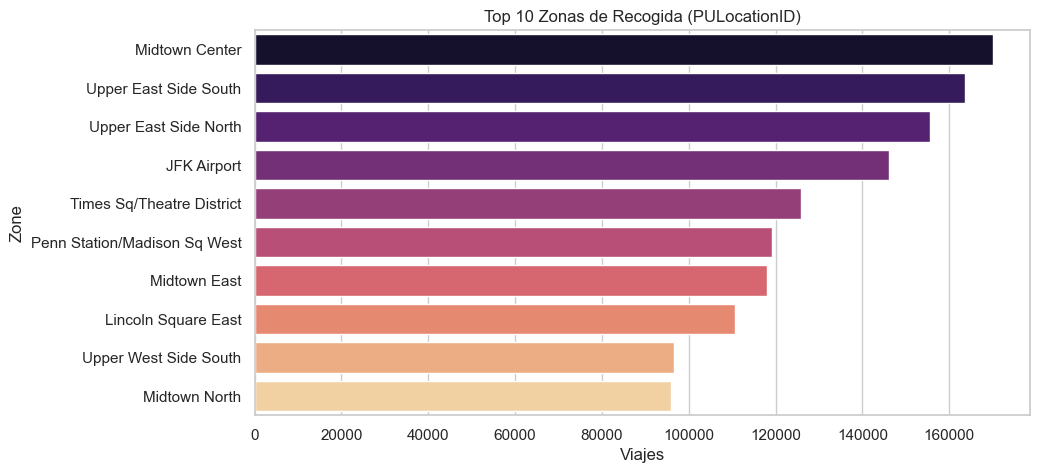

Vendors:


VendorID
2   78.264
1   21.687
7    0.035
6    0.014
Name: proportion, dtype: float64

Métodos de Pago:


payment_type
1   70.338
0   15.543
2   11.235
4    2.201
3    0.684
5    0.000
Name: proportion, dtype: float64

In [7]:
top_origen = df['PULocationID'].value_counts().head(10).reset_index()
top_origen.columns = ['LocationID', 'Viajes']
top_origen = top_origen.merge(lookup, on='LocationID', how='left')

plt.figure(figsize=(10, 5))
sns.barplot(data=top_origen, y='Zone', x='Viajes', palette='magma')
plt.title('Top 10 Zonas de Recogida (PULocationID)')
plt.savefig('../graficos/10_top_zonas.png')
plt.show()

print("Vendors:")
display(df['VendorID'].value_counts(normalize=True)*100)
print("Métodos de Pago:")
display(df['payment_type'].value_counts(normalize=True)*100)


## Paso 7 y 9: Tabla de Acciones Correctivas

In [8]:
# Construir tabla de acciones basada en hallazgos
acciones = [
    {"ID": 1, "Problema": "passenger_count nulo", "Cantidad": nulos_df.loc['passenger_count', 'Cantidad Nulos'] if 'passenger_count' in nulos_df.index else 0, "Porcentaje": f"{porcentaje_nulos.get('passenger_count', 0):.2f}%", "Severidad": "ALTA", "Acción Recomendada": "Imputar la moda (1) o flag", "Prioridad": "P0"},
    {"ID": 2, "Problema": "Tarifas negativas", "Cantidad": tarifas_negativas, "Porcentaje": f"{(tarifas_negativas/len(df))*100:.4f}%", "Severidad": "ALTA", "Acción Recomendada": "Eliminar registros", "Prioridad": "P0"},
    {"ID": 3, "Problema": "Distancia = 0", "Cantidad": distancias_0, "Porcentaje": f"{(distancias_0/len(df))*100:.2f}%", "Severidad": "MEDIA", "Acción Recomendada": "Filtrar viajes sin trayecto real", "Prioridad": "P1"},
    {"ID": 4, "Problema": "Distancias imposibles (>100)", "Cantidad": distancias_imposibles, "Porcentaje": f"{(distancias_imposibles/len(df))*100:.4f}%", "Severidad": "ALTA", "Acción Recomendada": "Eliminar outliers", "Prioridad": "P1"}
]
df_acciones = pd.DataFrame(acciones)
df_acciones.to_csv('../datos/acciones_correctivas.csv', index=False)
display(df_acciones)


,ID,Problema,Cantidad,Porcentaje,Severidad,Acción Recomendada,Prioridad
0,1,passenger_count nulo,540149,15.54%,ALTA,Imputar la moda (1) o flag,P0
1,2,Tarifas negativas,144118,4.1470%,ALTA,Eliminar registros,P0
2,3,Distancia = 0,90893,2.62%,MEDIA,Filtrar viajes sin trayecto real,P1
3,4,Distancias imposibles (>100),162,0.0047%,ALTA,Eliminar outliers,P1


## Paso 10: Insights de Negocio Iniciales
A partir del análisis realizado:
- **Volumen y Escala:** Tenemos ~3.47 millones de viajes en enero, lo que demuestra la vigencia y alta escala operativa. Hay ingresos generados de más de $80M usd.
- **Demanda:** La demanda es marcadamente más alta en la tarde-noche (horas punta entre las 17:00 y las 19:00). Las zonas top en recolección son indiscutiblemente del corazón de Manhattan y aeropuertos en Queens (JFK/LGA).
- **Calidad de Servicio (Datos):** Se identificó un ~15.5% de datos sin `passenger_count`, que se ha registrado como P0 en la tabla de acciones para corregirlo antes del modelo predictivo o de agregación del dashboard.
- **Outliers:** Existen anomalías claras de tarifas negativas (posiblemente reembolsos/errores de sistema) que representan un mínimo porcentaje pero deben removerse en la Etapa 2 de limpieza profunda.


In [10]:
end_time = time.time()
print(f"Ejecución del diagnóstico completada en {(end_time - start_time)/60:.2f} minutos.")


Ejecución del diagnóstico completada en 1597.13 minutos.
